<h1>Analisis actividad 1: Standing still</h1>

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
import seaborn as sns


In [5]:
actividad = 1

In [6]:
actividades = {
    1: "Standing still",
    2: "Sitting and relaxing",
    3: "Lying down",
    4: "Walking",
    5: "Climbing stairs",
    6: "Waist bends forward",
    7: "Frontal elevation of arms",
    8: "Knees bending",
    9: "Cycling",
    10: "Jogging",
    11: "Running",
    12: "Jump front & back"
}

<h1>Carga de Dataset</h1>

In [7]:

import glob
import pandas as pd
import re

# Busca todos los archivos
files = glob.glob(r"../DataSets/MHEALTHDATASET/mHealth_subject*.log")

dfs = []

for file in files:
    
    # Extraer número de sujeto desde el nombre del archivo
    subject_id = int(re.search(r"subject(\d+)", file).group(1))
    
    # Leer archivo
    df = pd.read_csv(file, sep='\t', header=None)
    
    # Agregar columna subject_id
    df["subject_id"] = subject_id
    
    dfs.append(df)

# Unir todos
MHEALTHDATASET = pd.concat(dfs, ignore_index=True)

# Asignar nombres de columnas
MHEALTHDATASET.columns = [  
    # Chest sensor
    "chest_acc_x",
    "chest_acc_y",
    "chest_acc_z",
    "ecg_1",
    "ecg_2",

    # Left ankle
    "ankle_acc_x",
    "ankle_acc_y",
    "ankle_acc_z",
    "ankle_gyro_x",
    "ankle_gyro_y",
    "ankle_gyro_z",
    "ankle_mag_x",
    "ankle_mag_y",
    "ankle_mag_z",

    # Right lower arm
    "arm_acc_x",
    "arm_acc_y",
    "arm_acc_z",
    "arm_gyro_x",
    "arm_gyro_y",
    "arm_gyro_z",
    "arm_mag_x",
    "arm_mag_y",
    "arm_mag_z",

    # Label
    "activity_label",
    
    # Nuevo
    "subject_id"
]

pd.set_option('display.max_columns', None)


In [8]:
## Filtramos para mostrar la actividad 
DATASET_ACTIVIDAD = MHEALTHDATASET[MHEALTHDATASET['activity_label'] == actividad]

# Le quitamos las etiquetas
DATASET_SENSORES_ACTIVIDAD = DATASET_ACTIVIDAD.drop(columns=['activity_label'])

<h1>Resumen estadístico</h1>

In [17]:
DATASET_SENSORES_ACTIVIDAD.describe()

,chest_acc_x,chest_acc_y,chest_acc_z,ecg_1,ecg_2,ankle_acc_x,ankle_acc_y,ankle_acc_z,ankle_gyro_x,ankle_gyro_y,ankle_gyro_z,ankle_mag_x,ankle_mag_y,ankle_mag_z,arm_acc_x,arm_acc_y,arm_acc_z,arm_gyro_x,arm_gyro_y,arm_gyro_z,arm_mag_x,arm_mag_y,arm_mag_z,subject_id
count,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000
mean,-9.613480,-0.699418,0.141333,0.014754,-0.000798,0.880712,-9.692594,1.090515,-0.082124,-0.663589,0.251740,0.221462,0.547318,-0.396483,-2.440308,-9.303726,1.139256,-0.340318,-0.746303,0.172305,0.355636,0.344874,-0.553059,5.500000
std,0.246040,0.660306,1.394403,0.463791,0.317936,0.951944,0.135990,0.574736,0.474947,0.164667,0.471595,0.731438,0.683585,0.376324,0.750628,0.250751,0.959020,0.472812,0.227104,0.455742,0.770587,1.793016,1.128690,2.872328
min,-10.951000,-2.597100,-2.654700,-1.595000,-1.276800,-1.806400,-10.584000,-1.016600,-0.684600,-0.906190,-0.634580,-7.254100,-24.017000,-5.138300,-4.876400,-10.438000,-1.616100,-0.907840,-1.110900,-0.543100,-9.893800,-30.916000,-14.096000,1.000000
25%,-9.769800,-1.172300,-0.609208,-0.142330,-0.117220,0.310645,-9.785100,0.567005,-0.491650,-0.765480,-0.123770,0.008828,0.366750,-0.590400,-3.008800,-9.492125,0.347485,-0.803920,-0.932240,-0.234910,0.170440,-0.019806,-1.077500,3.000000
50%,-9.659500,-0.829715,-0.104840,-0.071167,-0.041863,0.898125,-9.696200,1.065700,-0.196660,-0.675420,0.404720,0.198100,0.548480,-0.429720,-2.652650,-9.316450,1.248850,-0.349020,-0.737165,0.161640,0.362660,0.354020,-0.707520,5.500000
75%,-9.518375,-0.101852,0.823525,0.037677,0.037677,1.568600,-9.602000,1.546725,0.306120,-0.609760,0.640470,0.383160,0.730200,-0.158920,-2.195800,-9.100100,1.799325,0.056863,-0.650920,0.418100,0.551180,0.887550,0.000103,8.000000
max,-8.419300,0.949660,4.296100,4.902100,3.457900,2.815100,-8.660900,3.218000,0.781080,-0.212010,0.722990,16.400000,25.750000,3.683900,1.677700,-8.590800,3.242500,0.460780,-0.184800,0.995690,19.097000,57.527000,19.288000,10.000000


<h1>Correlación entre los atributos</h1>

In [9]:

DATASET_SENSORES_ACTIVIDAD.corr()

,chest_acc_x,chest_acc_y,chest_acc_z,ecg_1,ecg_2,ankle_acc_x,ankle_acc_y,ankle_acc_z,ankle_gyro_x,ankle_gyro_y,ankle_gyro_z,ankle_mag_x,ankle_mag_y,ankle_mag_z,arm_acc_x,arm_acc_y,arm_acc_z,arm_gyro_x,arm_gyro_y,arm_gyro_z,arm_mag_x,arm_mag_y,arm_mag_z,subject_id
chest_acc_x,1.000000,-0.274773,0.481898,-0.023828,-0.004294,0.145271,-0.083301,-0.315086,-0.304354,0.623020,0.340262,-0.038707,-0.003206,0.089630,-0.039817,-0.184587,-0.401701,-0.293183,0.649828,-0.220522,-0.021467,-0.003405,-0.008679,0.404025
chest_acc_y,-0.274773,1.000000,0.012491,-0.011871,-0.051185,0.092394,0.232564,-0.189329,0.241693,-0.344275,-0.295196,0.008262,-0.048678,-0.046396,-0.359387,0.264832,0.037095,0.181235,-0.231710,0.053878,-0.045348,-0.009557,0.052416,-0.567174
chest_acc_z,0.481898,0.012491,1.000000,-0.021175,-0.042845,0.268916,0.056295,-0.560166,-0.340003,0.555776,0.023822,-0.066763,-0.034846,0.157881,-0.248088,-0.010210,-0.260874,-0.148811,0.518010,-0.414808,-0.043797,-0.015668,0.039671,-0.214886
ecg_1,-0.023828,-0.011871,-0.021175,1.000000,0.831118,-0.046066,-0.001010,0.055917,-0.017702,0.003099,0.043979,-0.009952,-0.005167,0.030035,0.035932,-0.004174,0.041453,-0.029705,0.018601,0.032076,0.005015,0.006689,0.009595,-0.003460
ecg_2,-0.004294,-0.051185,-0.042845,0.831118,1.000000,0.005130,-0.000043,0.017476,0.080043,0.037397,0.038201,0.008465,0.002155,-0.013956,0.058205,-0.018007,0.020648,0.048031,0.005231,0.099687,0.016742,0.013367,0.007857,0.041547
ankle_acc_x,0.145271,0.092394,0.268916,-0.046066,0.005130,1.000000,0.232551,-0.702204,0.321663,-0.139855,-0.639791,0.146179,-0.002954,-0.370389,-0.552603,0.356284,-0.034387,0.591544,-0.178991,-0.278404,0.052230,0.016199,-0.058190,-0.049813
ankle_acc_y,-0.083301,0.232564,0.056295,-0.001010,-0.000043,0.232551,1.000000,-0.009920,0.162406,-0.039192,-0.235513,0.039287,-0.020199,-0.111561,0.147389,-0.009930,0.105226,0.293334,-0.212830,0.021183,-0.006827,0.007931,0.006098,-0.355418
ankle_acc_z,-0.315086,-0.189329,-0.560166,0.055917,0.017476,-0.702204,-0.009920,1.000000,-0.054532,-0.146416,0.286414,-0.080261,0.018486,0.257392,0.598655,-0.084318,0.457326,-0.147571,-0.188242,0.392770,-0.022019,-0.004725,0.005576,0.006940
ankle_gyro_x,-0.304354,0.241693,-0.340003,-0.017702,0.080043,0.321663,0.162406,-0.054532,1.000000,-0.240423,-0.363827,0.092221,-0.036350,-0.223826,-0.150472,0.352500,0.338298,0.844997,-0.500426,0.698832,0.027257,0.012722,-0.024954,-0.268262
ankle_gyro_y,0.623020,-0.344275,0.555776,0.003099,0.037397,-0.139855,-0.039192,-0.146416,-0.240423,1.000000,0.669980,-0.073849,-0.017079,0.190232,0.343164,-0.486085,-0.456107,-0.362323,0.807196,0.064443,-0.046688,-0.000522,0.032967,0.277237


<h1>Histograma de la Actividad</h1>

<function matplotlib.pyplot.show(close=None, block=None)>

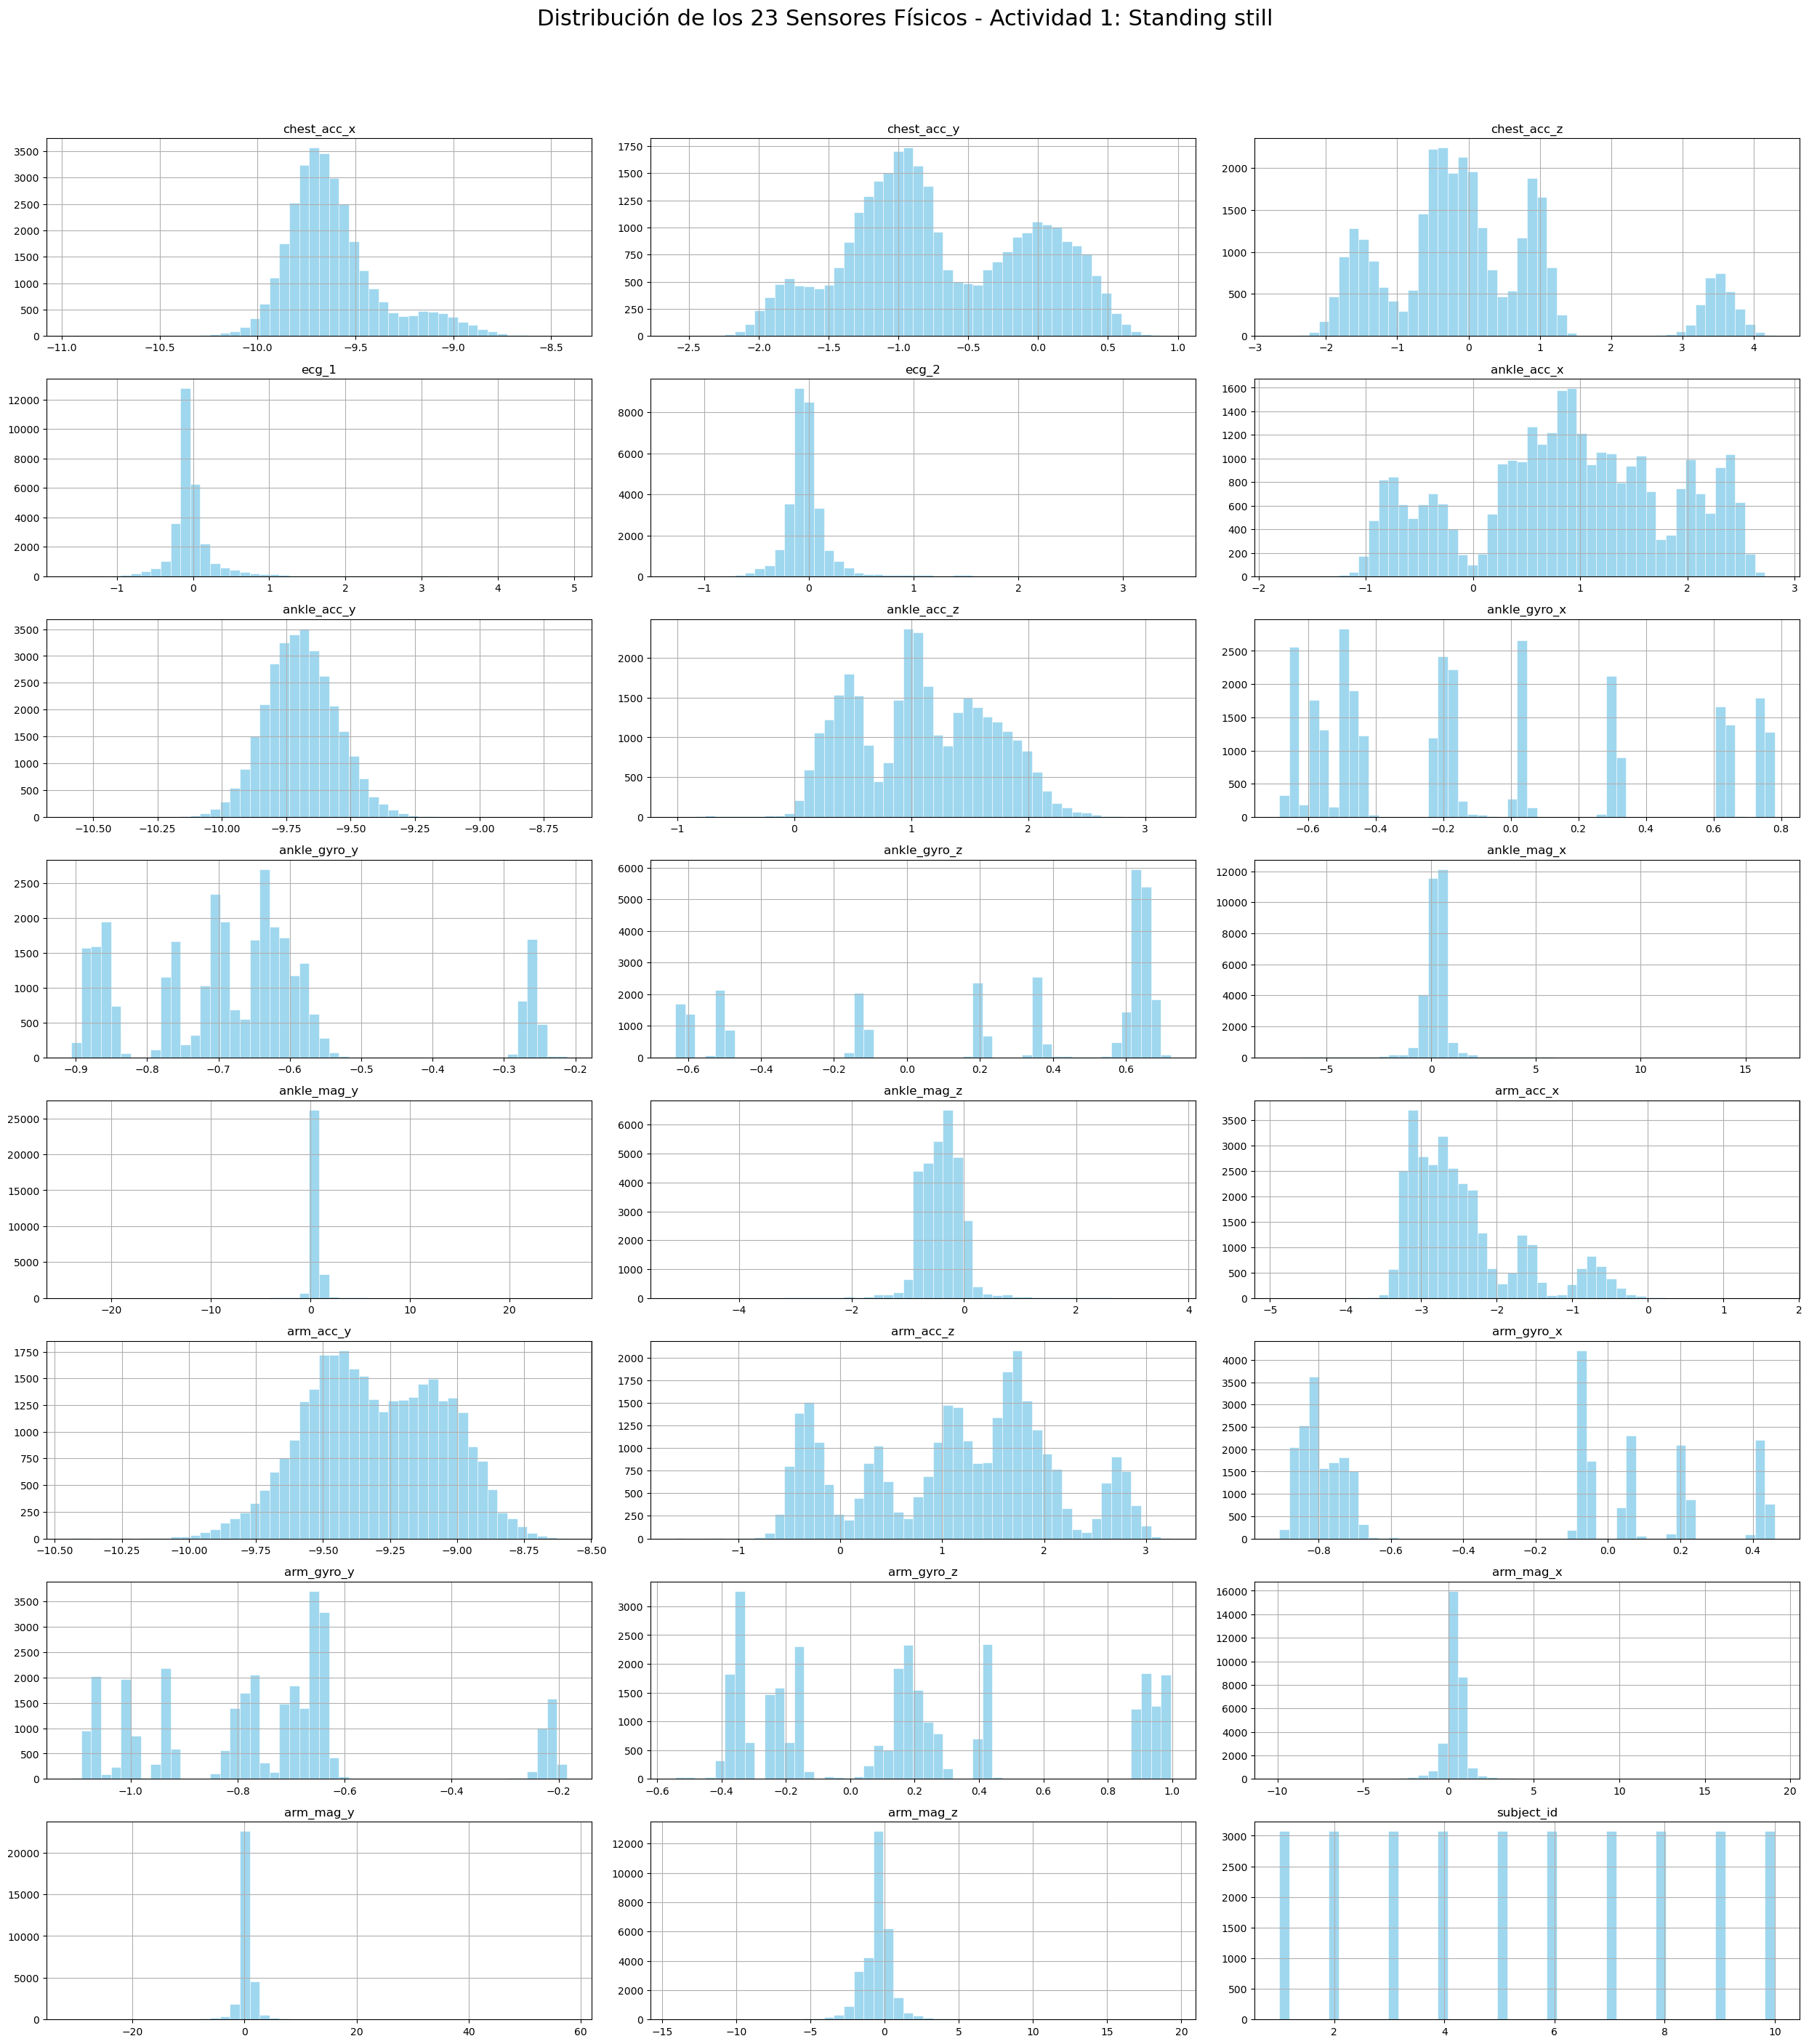

In [10]:


DATASET_SENSORES_ACTIVIDAD.hist(
    bins=50, 
    layout=(15,3),
    figsize=(25, 50), 
    color='skyblue', 
    edgecolor='white', 
    linewidth=0.5,
    alpha=0.8
)

plt.suptitle(f"Distribución de los 23 Sensores Físicos - Actividad {actividad}: {actividades[actividad]}", fontsize=22, y=1.02)
plt.tight_layout()

plt.show

<h1>Outliers</h1>

In [11]:

outliers_info = []

for col in DATASET_SENSORES_ACTIVIDAD.select_dtypes(include="number").columns:
    
    Q1 = DATASET_SENSORES_ACTIVIDAD[col].quantile(0.25)
    Q3 = DATASET_SENSORES_ACTIVIDAD[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    mask_outliers = (DATASET_SENSORES_ACTIVIDAD[col] < lower) | (DATASET_SENSORES_ACTIVIDAD[col] > upper)
    
    total_outliers = mask_outliers.sum()
    percentage = mask_outliers.mean() * 100
    
    outliers_info.append({
        "Sensor": col,
        "Total_Outliers": total_outliers,
        "Porcentaje_Outliers (%)": round(percentage, 2)
    })

outliers_df = pd.DataFrame(outliers_info)

outliers_df

,Sensor,Total_Outliers,Porcentaje_Outliers (%)
0,chest_acc_x,2273,7.40
1,chest_acc_y,0,0.00
2,chest_acc_z,3023,9.84
3,ecg_1,4258,13.86
4,ecg_2,3147,10.24
5,ankle_acc_x,4,0.01
6,ankle_acc_y,245,0.80
7,ankle_acc_z,6,0.02
8,ankle_gyro_x,0,0.00
9,ankle_gyro_y,3072,10.00


<h1>Gráfica de densidad</h1>

<function matplotlib.pyplot.show(close=None, block=None)>

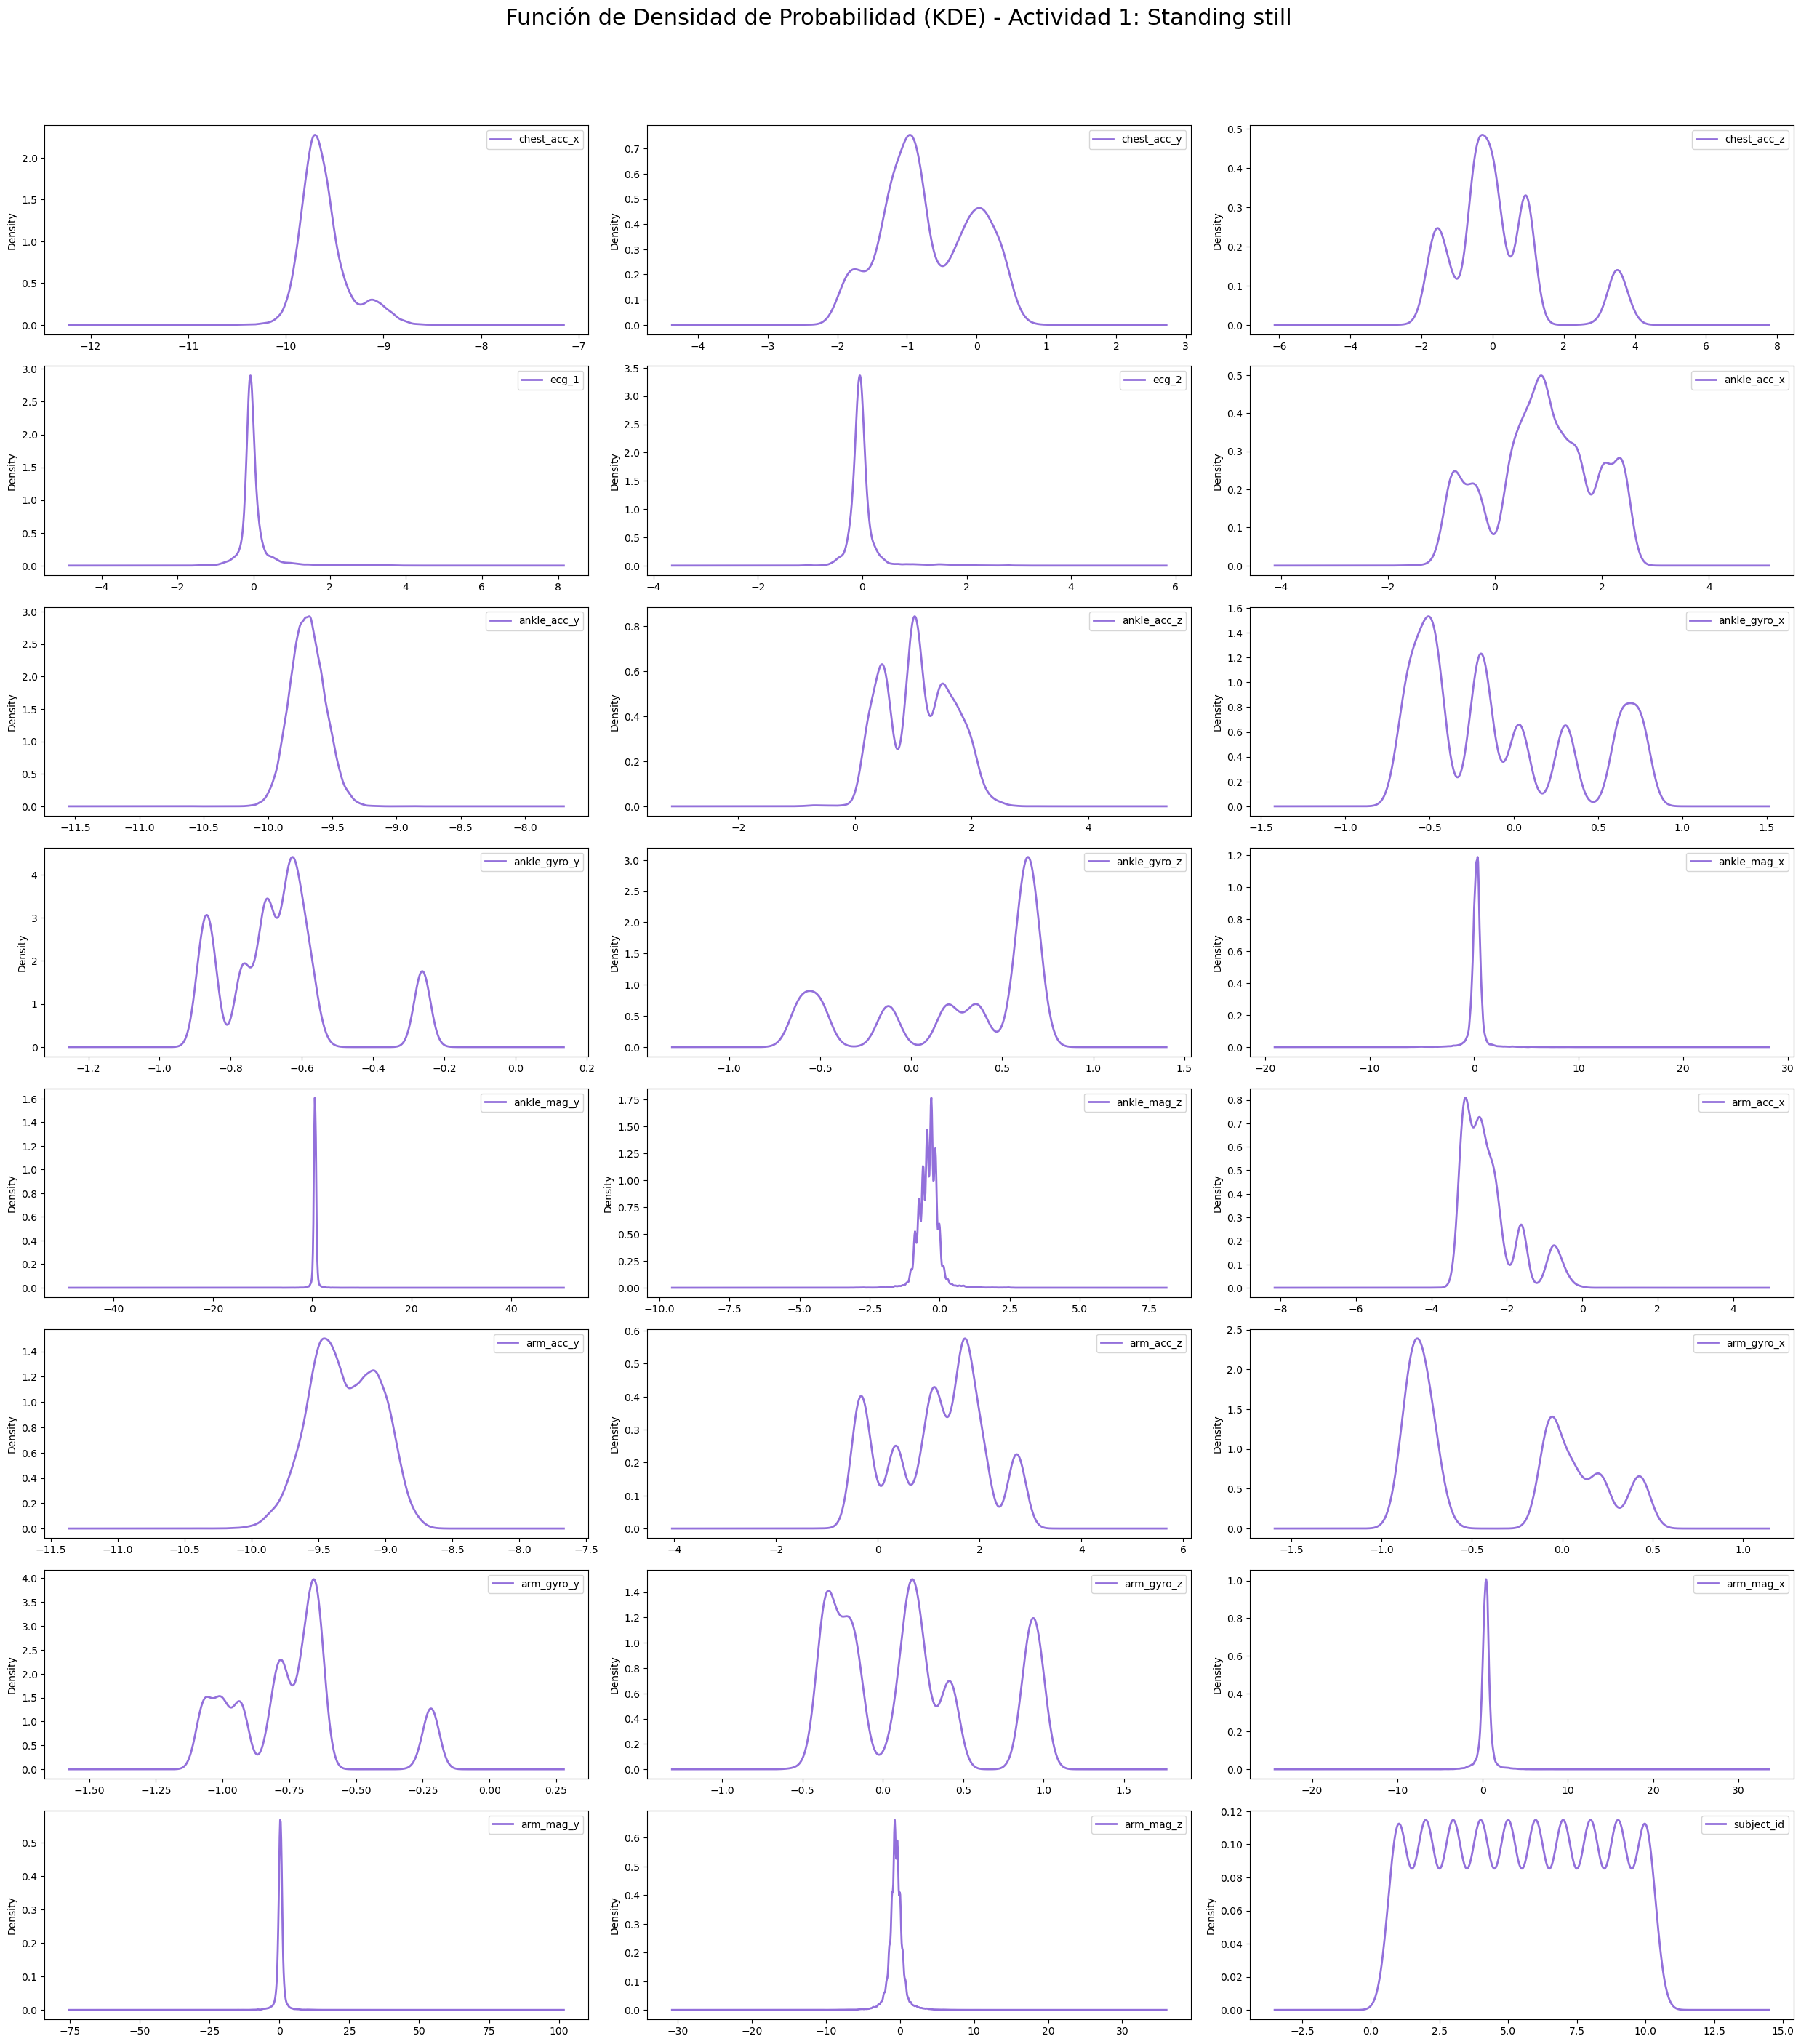

In [12]:
DATASET_SENSORES_ACTIVIDAD.plot(
    kind='density', 
    subplots=True, 
    layout=(15, 3),  
    figsize=(25, 50),
    sharex=False,     
    color='mediumpurple', 
    linewidth=2
)

plt.suptitle(f"Función de Densidad de Probabilidad (KDE) - Actividad {actividad}: {actividades[actividad]}", fontsize=22, y=1.02)
plt.tight_layout()

plt.show

<h1>Gráfica de cajas y bigotes</h1>

<function matplotlib.pyplot.show(close=None, block=None)>

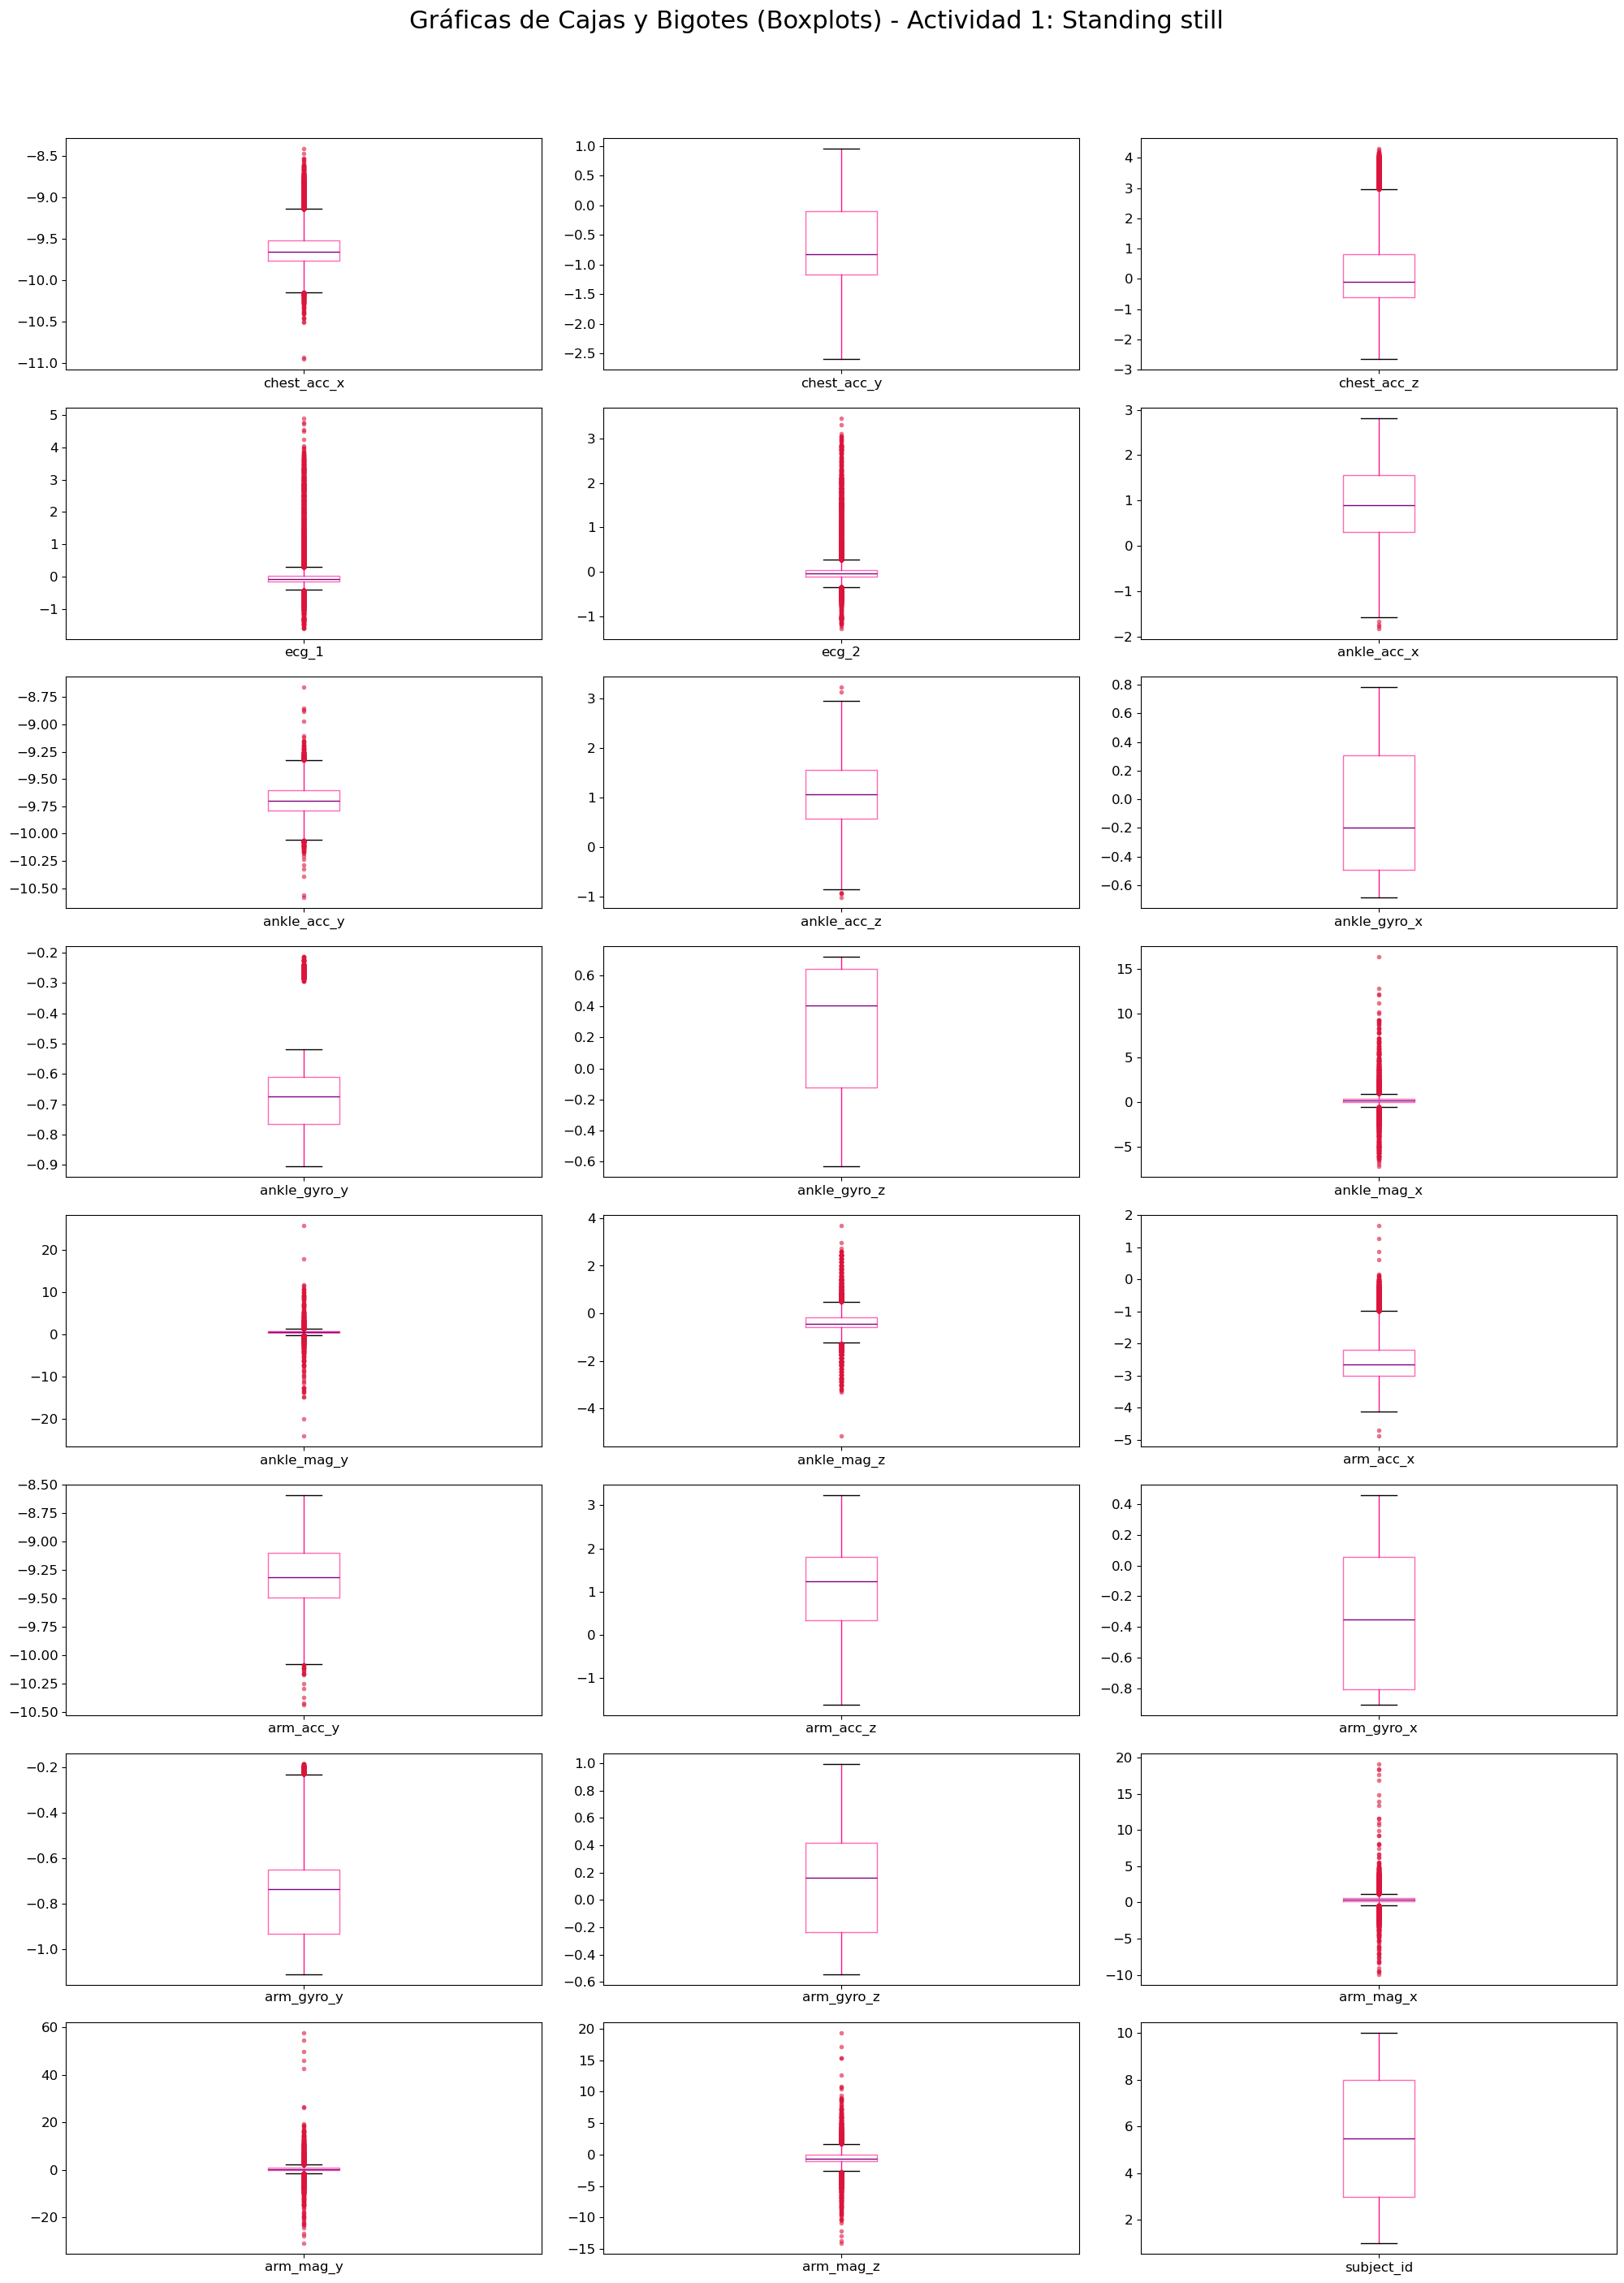

In [13]:
color_props = dict(boxes='hotpink', whiskers='deeppink', medians='purple', caps='black')
puntitos_props = dict(marker='o', markerfacecolor='crimson', markersize=4, alpha=0.6, markeredgecolor='none')

# Dibujamos el mosaico
DATASET_SENSORES_ACTIVIDAD.plot(
    kind='box', 
    subplots=True, 
    layout=(15, 3),  
    figsize=(20, 50), 
    color=color_props,
    flierprops=puntitos_props,
    fontsize=12      
)


plt.suptitle(f'Gráficas de Cajas y Bigotes (Boxplots) - Actividad {actividad}: {actividades[actividad]}', fontsize=22, y=1.02)
plt.tight_layout()

plt.show

<h1>Matriz de correlación</h1>

<function matplotlib.pyplot.show(close=None, block=None)>

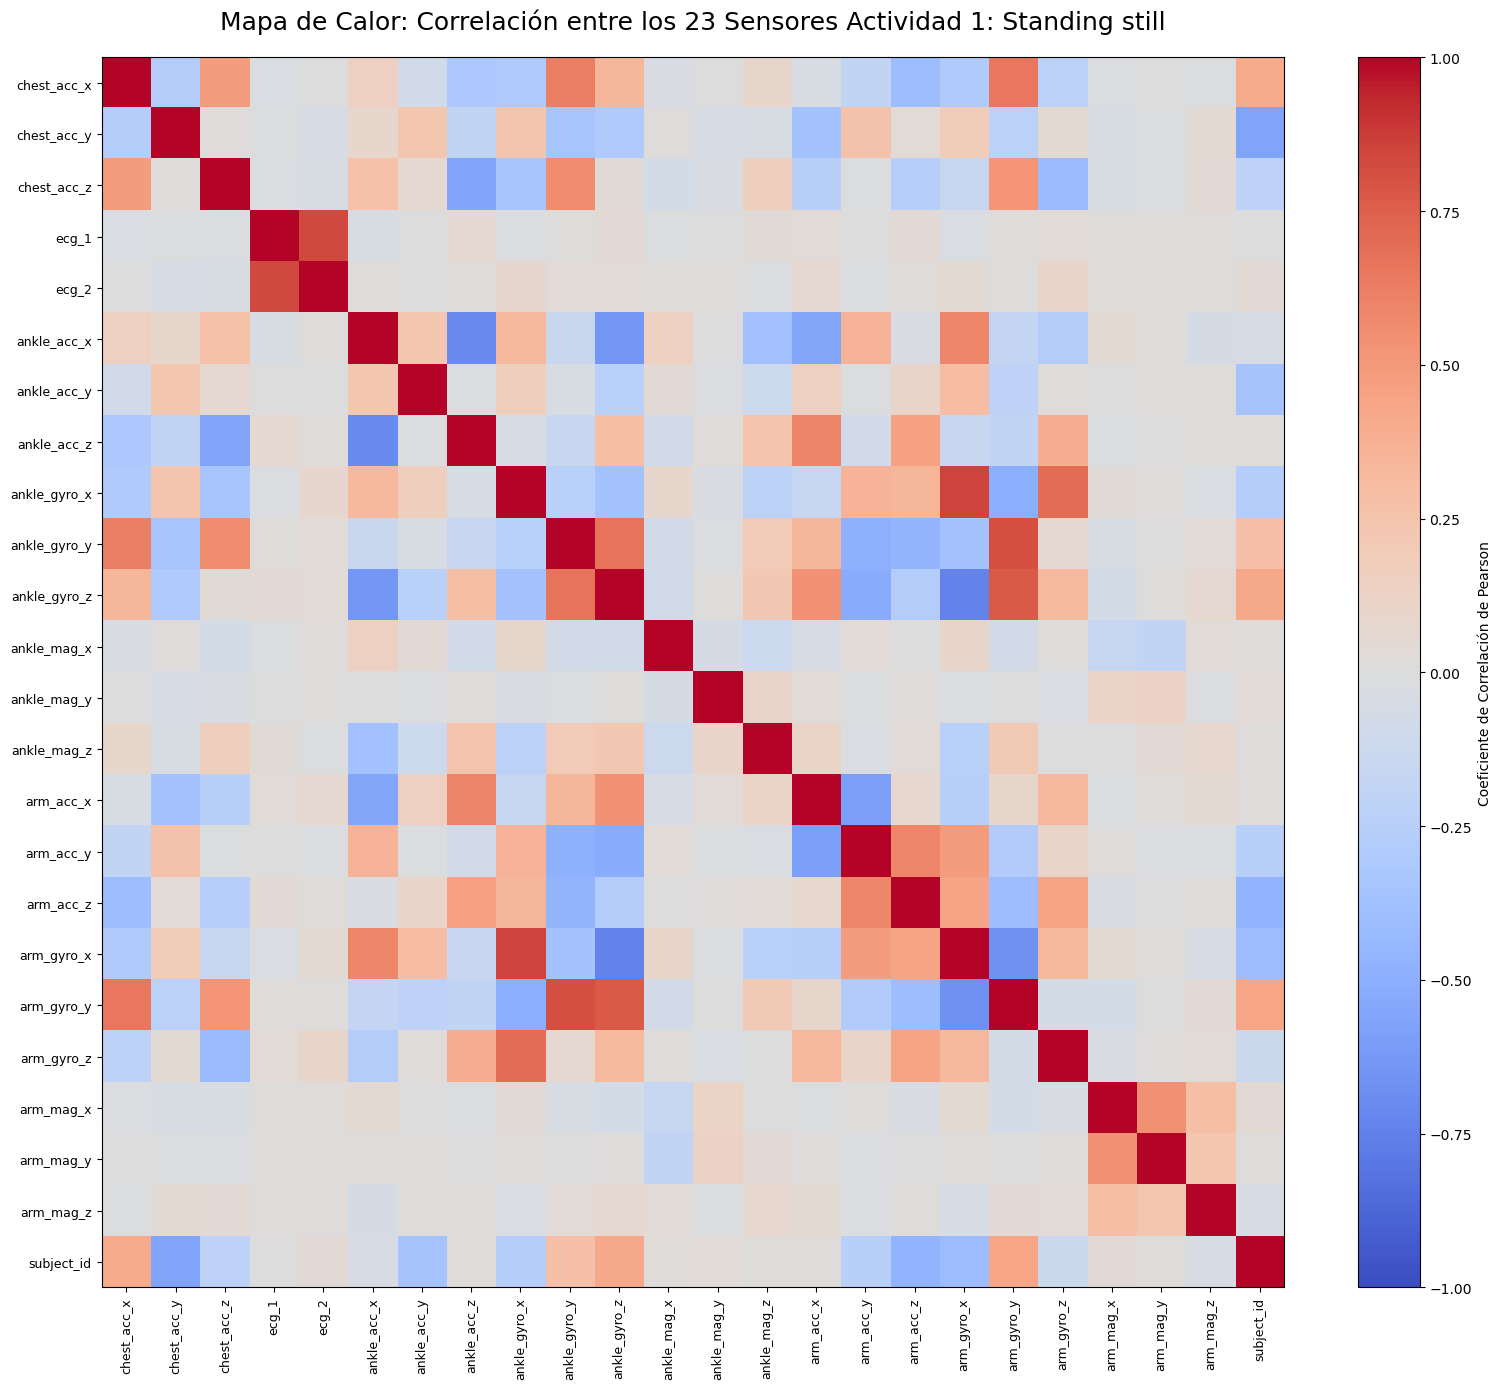

In [14]:
# Calculamos la matriz de correlación de Pearson
matriz_correlacion = DATASET_SENSORES_ACTIVIDAD.corr()

# Dibujamos el Mapa de Calor
plt.figure(figsize=(16, 14))

# Usamos imshow para dibujar la cuadrícula, coolwarm da rojo a los +1 y azul a los -1
imagen = plt.imshow(matriz_correlacion, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')

# Agregamos la barra de colores al lado
plt.colorbar(imagen, label='Coeficiente de Correlación de Pearson')
plt.title(f'Mapa de Calor: Correlación entre los 23 Sensores Actividad {actividad}: {actividades[1]}', fontsize=18, pad=20)

# Ponemos los nombres de las 45 columnas en los bordes
posiciones = np.arange(len(DATASET_SENSORES_ACTIVIDAD.columns))
plt.xticks(posiciones, DATASET_SENSORES_ACTIVIDAD.columns, rotation=90, fontsize=9)
plt.yticks(posiciones, DATASET_SENSORES_ACTIVIDAD.columns, fontsize=9)

plt.grid(False) 
plt.tight_layout()

plt.show

<h1>Matriz de dispersión</h1>

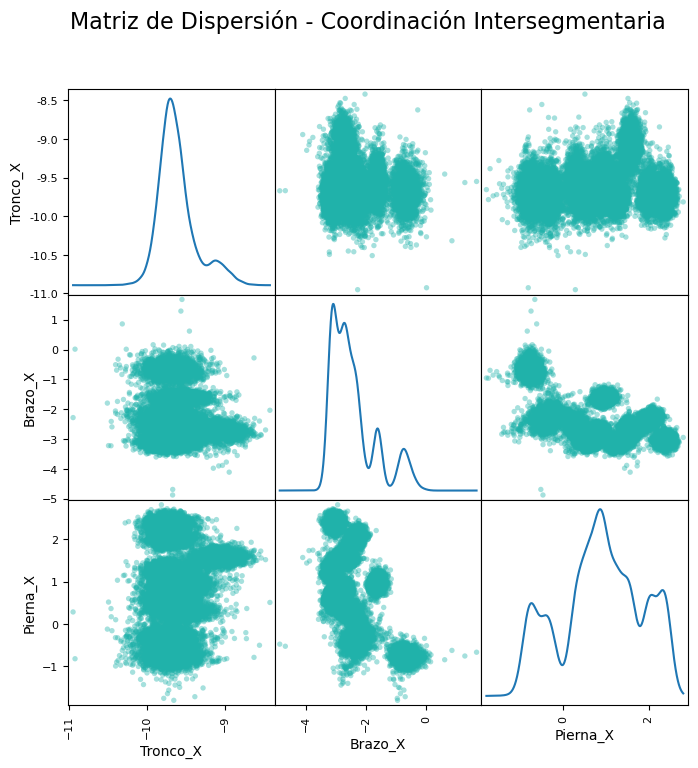

In [15]:
# Selección estratégica: un eje X por segmento corporal
sensores_estrategicos = [
    "chest_acc_x",   # Tronco
    "arm_acc_x",     # Brazo derecho
    "ankle_acc_x"    # Pierna
]

datos_scatter = DATASET_SENSORES_ACTIVIDAD[sensores_estrategicos].copy()


datos_scatter.columns = [
    "Tronco_X",
    "Brazo_X",
    "Pierna_X"
]

pd.plotting.scatter_matrix(
    datos_scatter,
    alpha=0.4,
    figsize=(8, 8),
    diagonal='kde',
    color='lightseagreen',
    marker='o',
    s=15
)

plt.suptitle(
    'Matriz de Dispersión - Coordinación Intersegmentaria',
    fontsize=16
)

plt.show()

<h1>Matriz de dispersión por sujeto</h1>

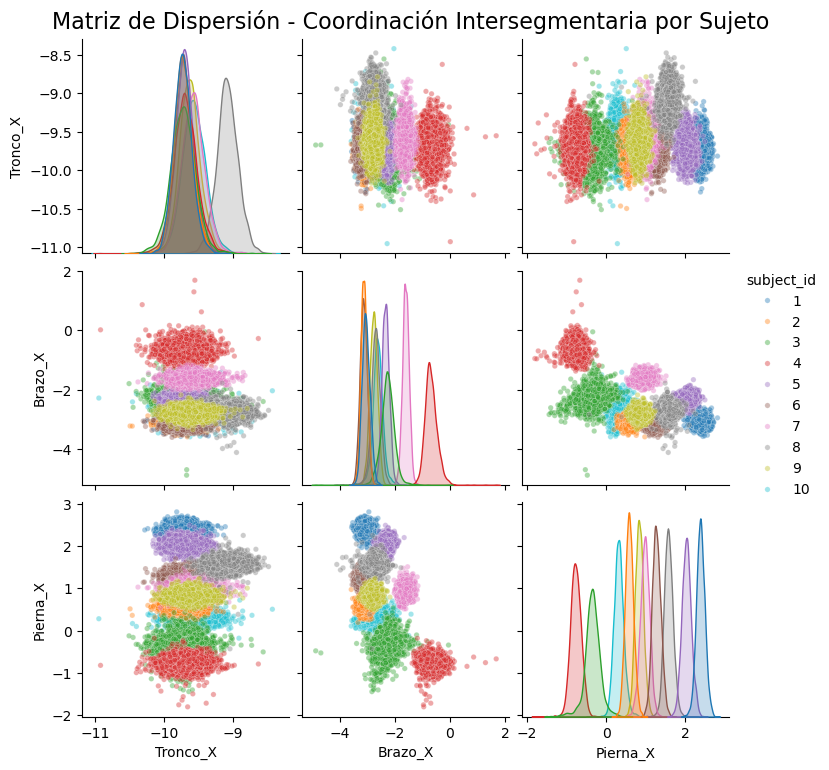

In [16]:
# Selección estratégica
sensores_estrategicos = [
    "chest_acc_x",   # Tronco
    "arm_acc_x",     # Brazo derecho
    "ankle_acc_x"    # Pierna
]

datos_scatter = DATASET_SENSORES_ACTIVIDAD[sensores_estrategicos + ["subject_id"]].copy()

datos_scatter.columns = [
    "Tronco_X",
    "Brazo_X",
    "Pierna_X",
    "subject_id"
]

# Convertir a categoría (importante para que seaborn lo trate como grupo)
datos_scatter["subject_id"] = datos_scatter["subject_id"].astype("category")

# Pairplot con color por sujeto
sns.pairplot(
    datos_scatter,
    vars=["Tronco_X", "Brazo_X", "Pierna_X"],
    hue="subject_id",
    diag_kind="kde",
    plot_kws={"alpha": 0.4, "s": 15}
)

plt.suptitle(
    'Matriz de Dispersión - Coordinación Intersegmentaria por Sujeto',
    y=1.02,
    fontsize=16
)

plt.show()